# PTB-XL ECG Machine Learning Capstone: Classification Track (Part B)
## Objective: Ensemble & Neural Models for Dominant Cardiac Diagnostic Category

This notebook implements **Classification Track Part B** under the Capstone rubric.
Using the *identical* patient-stratified test split partition saved from Part A (BUG-08 fixed) and identical leak-free preprocessing pipeline, it benchmarks five advanced learners:

1. **AdaBoost Classifier** — adaptive boosting on Decision Stump base learners
2. **Gradient Boosting Machine (GBM)** — stage-wise additive boosting
3. **XGBoost Classifier** — extreme gradient boosting with `logloss` objective
4. **Bagging Classifier** — variance-reduction ensemble of Decision Trees
5. **Multi-Layer Perceptron (MLP)** — fully connected neural classifier

All models are evaluated on **Accuracy**, **Weighted-F1**, and **Macro-F1** (BUG-18 fixed).


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
palette = sns.color_palette('Set2')

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("WARNING: xgboost not installed — XGBClassifier will be skipped.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded. XGBoost available:", HAS_XGB)


Libraries loaded. XGBoost available: True


---
## Section A: Data Ingestion, Label Collapse & Shared Patient-Stratified Split (BUG-08 Fix)


In [2]:
# Path resolution (BUG-17)
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

features_df = pd.read_csv(os.path.join(DATA_DIR, 'stage4_features.csv'))
labels_df   = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_labels.csv'))

label_targets = ['label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP']
df = features_df.merge(
    labels_df[['ecg_id', 'fold'] + label_targets],
    on='ecg_id', how='inner'
)

# Single-label hierarchy collapse
priority_cols = ['label_MI', 'label_CD', 'label_HYP', 'label_STTC', 'label_NORM']
class_names   = ['MI', 'CD', 'HYP', 'STTC', 'NORM']

def collapse_dominant_label(row):
    for col, name in zip(priority_cols, class_names):
        if row[col] == 1:
            return name
    raise ValueError(f"Record {row['ecg_id']} has zero positive labels!")

df['dominant_label'] = df.apply(collapse_dominant_label, axis=1)

# Encode labels to integers for XGBoost compatibility
le = LabelEncoder()
le.fit(class_names)
df['y_int'] = le.transform(df['dominant_label'])

print(f"Total records: {len(df)}")


Total records: 21388


In [3]:
# Feature matrix discovery (BUG-03: exclude delineation_ok)
exclude_cols = {
    'ecg_id', 'patient_id', 'fold', 'dominant_label', 'y_int', 'delineation_ok',
    'label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP'
}
feature_cols = [c for c in df.columns if c not in exclude_cols
                and pd.api.types.is_numeric_dtype(df[c])]

# Engineer qtc_qrs_ratio using correct column names (BUG-02)
if 'qtc_mean_ms' in df.columns and 'qrs_dur_mean_ms' in df.columns:
    df['qtc_qrs_ratio'] = df['qtc_mean_ms'] / (df['qrs_dur_mean_ms'].replace(0, np.nan))
    if 'qtc_qrs_ratio' not in feature_cols:
        feature_cols.append('qtc_qrs_ratio')
        print("Engineered feature 'qtc_qrs_ratio' added.")

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Apply guard-masking on unverified conduction intervals (BUG-04)
guard_cols = [
    'pr_mean_ms', 'pr_std_ms', 'qrs_dur_mean_ms', 'qrs_dur_std_ms',
    'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms'
]
df.loc[~df['delineation_ok'].astype(bool), guard_cols] = np.nan


Engineered feature 'qtc_qrs_ratio' added.
Feature columns (26): ['n_beats', 'hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rr_rmssd_ms', 'rr_pnn50', 'n_qrs_reliable', 'frac_qrs_reliable', 'pr_mean_ms', 'pr_std_ms', 'qrs_dur_mean_ms', 'qrs_dur_std_ms', 'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms', 'p_dur_mean_ms', 't_dur_mean_ms', 'p_amp_median_mv', 'r_amp_median_mv', 't_amp_median_mv', 'st_level_median_mv', 'qrs_area_median', 'p_area_median', 't_area_median', 'rs_ratio_median', 'qtc_qrs_ratio']


In [4]:
# Partition loading: Use identical test split persisted from Part A (BUG-08)
split_info_path = os.path.join(DATA_DIR, 'split_indices.json')

if os.path.exists(split_info_path):
    with open(split_info_path, 'r') as f:
        split_data = json.load(f)
    test_ecg_ids = set(split_data['test_ecg_ids'])
    test_mask = df['ecg_id'].isin(test_ecg_ids)
    train_idx = np.where(~test_mask)[0]
    test_idx = np.where(test_mask)[0]
    print(f"Loaded exact shared test split from Part A: {len(test_idx)} test records")
else:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, test_idx = next(sgkf.split(df, df['dominant_label'], groups=df['patient_id']))
    print(f"Fallback StratifiedGroupKFold generated test split: {len(test_idx)} records")

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

train_patients = set(train_df['patient_id'])
test_patients  = set(test_df['patient_id'])
overlap = train_patients & test_patients
assert len(overlap) == 0, f"LEAKAGE DETECTED: {len(overlap)} patients in both sets!"

# Preprocessing (fit on train only)
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_raw = train_df[feature_cols].values
X_test_raw  = test_df[feature_cols].values

y_train_str = train_df['dominant_label'].values
y_test_str  = test_df['dominant_label'].values

y_train_int = train_df['y_int'].values
y_test_int  = test_df['y_int'].values

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_test  = scaler.transform(imputer.transform(X_test_raw))

# Create inner CV splits generator for leak-free tuning (BUG-06)
sgkf_inner = StratifiedGroupKFold(n_splits=3)
clf_cv_splits = list(sgkf_inner.split(X_train_raw, y_train_str, groups=train_df['patient_id']))

print("Preprocessing complete.")


Loaded exact shared test split from Part A: 4278 test records


Preprocessing complete.


---
## Section B: Model Training — Ensemble & Neural Classifiers


In [5]:
clf_results  = []
clf_cms      = {}
clf_models   = {}
clf_pipelines = {}

def compute_ovr_auc(model, X_te, y_te_str, class_names=None):
    try:
        probs = model.predict_proba(X_te)
    except AttributeError:
        return np.nan
    y_te_bin = label_binarize(y_te_str, classes=model.classes_)
    return roc_auc_score(y_te_bin, probs, average='weighted', multi_class='ovr')

def eval_clf(name, model, X_te, y_te, pipeline_obj=None):
    'Predict on pre-fitted test set and record metrics including Macro-F1 (BUG-12, BUG-18).'
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    prec  = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec   = recall_score(y_te, preds, average='weighted', zero_division=0)
    wf1   = f1_score(y_te, preds, average='weighted', zero_division=0)
    mf1   = f1_score(y_te, preds, average='macro', zero_division=0)
    auc_v = compute_ovr_auc(model, X_te, y_te, class_names)
    clf_results.append({
        'Algorithm': name,
        'Accuracy': round(acc, 4),
        'Precision_Weighted': round(prec, 4),
        'Recall_Weighted': round(rec, 4),
        'Weighted_F1': round(wf1, 4),
        'Macro_F1': round(mf1, 4),
        'ROC_AUC_OvR': round(auc_v, 4)
    })
    clf_cms[name]    = confusion_matrix(y_te, preds, labels=class_names)
    clf_models[name] = model
    if pipeline_obj is not None:
        clf_pipelines[name] = pipeline_obj
    print(f"[{name}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  Weighted-F1={wf1:.4f}  Macro-F1={mf1:.4f}  ROC-AUC={auc_v:.4f}")
    return model

print("Model evaluation helper ready.")


Model evaluation helper ready.


Random Forest best n_estimators=300
[Random Forest]  Acc=0.6094  Prec=0.5838  Rec=0.6094  Weighted-F1=0.5739  Macro-F1=0.4495  ROC-AUC=0.8317


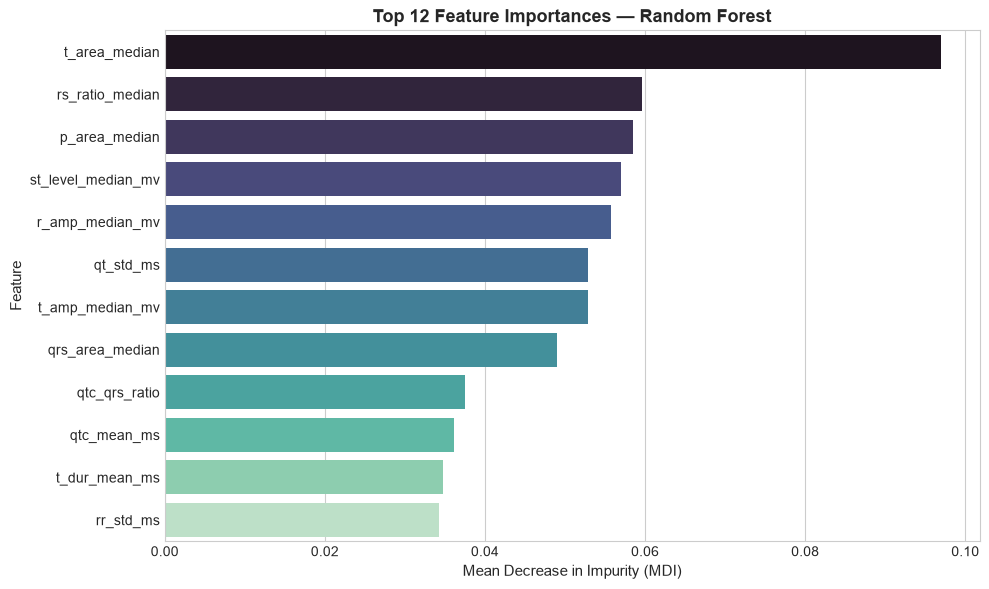

In [6]:
# ── 1. Random Forest ──────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={'model__n_estimators': [100, 200, 300, 400]},
    cv=clf_cv_splits, scoring='f1_weighted', n_jobs=-1
)
rf_grid.fit(X_train_raw, y_train_str)
best_rf_pipe = rf_grid.best_estimator_
best_rf_model = best_rf_pipe.named_steps['model']
print(f"Random Forest best n_estimators={rf_grid.best_params_['model__n_estimators']}")
eval_clf('Random Forest', best_rf_model, X_test, y_test_str, best_rf_pipe)

# Feature Importance plot for Random Forest
rf_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': best_rf_model.feature_importances_})
rf_imp = rf_imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_imp.head(12), x='Importance', y='Feature', palette='mako')
plt.title(f'Top 12 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


In [7]:
# ── 2. AdaBoost ───────────────────────────────────────────────────────────
ada_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=RANDOM_STATE))
])

ada_grid = GridSearchCV(
    ada_pipe,
    param_grid={'model__n_estimators': [100, 300, 500], 'model__learning_rate': [0.1, 0.5, 1.0]},
    cv=clf_cv_splits, scoring='f1_weighted', n_jobs=-1
)
ada_grid.fit(X_train_raw, y_train_str)
best_ada_pipe = ada_grid.best_estimator_
print(f"AdaBoost best params: {ada_grid.best_params_}")
eval_clf('AdaBoost', best_ada_pipe.named_steps['model'], X_test, y_test_str, best_ada_pipe)


AdaBoost best params: {'model__learning_rate': 1.0, 'model__n_estimators': 500}


[AdaBoost]  Acc=0.5832  Prec=0.5564  Rec=0.5832  Weighted-F1=0.5563  Macro-F1=0.4542  ROC-AUC=0.8021


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](5,)","['CD','HYP','MI','NORM','STTC']"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](500,)","[0.48,0.67,0.63,...,0.8 ,0.8 ,0.8 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](500,)","[1.47,0.66,0.86,...,0.02,0.02,0.02]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](26,)","[0. ,0.02,0.01,...,0.18,0.07,0.01]"


In [8]:
# ── 3. Gradient Boosting Machine (GBM) [Supplementary] ────────────────────
gbm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE))
])

gbm_grid = GridSearchCV(
    gbm_pipe,
    param_grid={'model__learning_rate': [0.05, 0.1, 0.2]},
    cv=clf_cv_splits, scoring='f1_weighted', n_jobs=-1
)
gbm_grid.fit(X_train_raw, y_train_str)
best_gbm_pipe = gbm_grid.best_estimator_
print(f"GBM best learning_rate={gbm_grid.best_params_['model__learning_rate']}")
eval_clf('GBM (Supplementary)', best_gbm_pipe.named_steps['model'], X_test, y_test_str, best_gbm_pipe)


GBM best learning_rate=0.1
[GBM (Supplementary)]  Acc=0.6068  Prec=0.5792  Rec=0.6068  Weighted-F1=0.5818  Macro-F1=0.4726  ROC-AUC=0.8358


,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [9]:
# ── 4. XGBoost (Rubric Item 8) ───────────────────────────────────────────
if HAS_XGB:
    # Outer XGBoost grid using int target labels
    xgb_model_base = XGBClassifier(
        objective='multi:softmax', num_class=5, eval_metric='mlogloss',
        n_estimators=200, random_state=RANDOM_STATE, verbosity=0
    )
    # Generate CV splits for int labels
    xgb_cv_splits = list(sgkf_inner.split(X_train_raw, y_train_int, groups=train_df['patient_id']))
    
    xgb_grid = GridSearchCV(
        xgb_model_base,
        param_grid={'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.1, 0.2]},
        cv=xgb_cv_splits, scoring='f1_weighted', n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train_int)
    best_xgb = xgb_grid.best_estimator_
    print(f"XGBoost best params: {xgb_grid.best_params_}")
    
    xgb_preds_int = best_xgb.predict(X_test)
    xgb_preds_str = le.inverse_transform(xgb_preds_int)
    xgb_probs     = best_xgb.predict_proba(X_test)
    y_test_bin    = label_binarize(y_test_int, classes=best_xgb.classes_)
    xgb_auc       = roc_auc_score(y_test_bin, xgb_probs, average='weighted', multi_class='ovr')
    acc   = accuracy_score(y_test_str, xgb_preds_str)
    prec  = precision_score(y_test_str, xgb_preds_str, average='weighted', zero_division=0)
    rec   = recall_score(y_test_str, xgb_preds_str, average='weighted', zero_division=0)
    wf1   = f1_score(y_test_str, xgb_preds_str, average='weighted', zero_division=0)
    mf1   = f1_score(y_test_str, xgb_preds_str, average='macro', zero_division=0)

    clf_results.append({
        'Algorithm': 'XGBoost',
        'Accuracy': round(acc, 4),
        'Precision_Weighted': round(prec, 4),
        'Recall_Weighted': round(rec, 4),
        'Weighted_F1': round(wf1, 4),
        'Macro_F1': round(mf1, 4),
        'ROC_AUC_OvR': round(xgb_auc, 4)
    })
    clf_cms['XGBoost']    = confusion_matrix(y_test_str, xgb_preds_str, labels=class_names)
    clf_models['XGBoost'] = best_xgb
    xgb_pipe = Pipeline([('imputer', imputer), ('scaler', scaler), ('model', best_xgb)])
    clf_pipelines['XGBoost'] = xgb_pipe
    print(f"[XGBoost]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  Weighted-F1={wf1:.4f}  Macro-F1={mf1:.4f}  ROC-AUC={xgb_auc:.4f}")


XGBoost best params: {'learning_rate': 0.2, 'max_depth': 3}
[XGBoost]  Acc=0.6169  Prec=0.5933  Rec=0.6169  Weighted-F1=0.5909  Macro-F1=0.4816  ROC-AUC=0.8405


In [10]:
# ── 5. Bagging Classifier ─────────────────────────────────────────────────
bag_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=6), random_state=RANDOM_STATE, n_jobs=-1))
])

bag_grid = GridSearchCV(
    bag_pipe,
    param_grid={'model__n_estimators': [100, 200, 300]},
    cv=clf_cv_splits, scoring='f1_weighted', n_jobs=-1
)
bag_grid.fit(X_train_raw, y_train_str)
best_bag_pipe = bag_grid.best_estimator_
print(f"Bagging best n_estimators={bag_grid.best_params_['model__n_estimators']}")
eval_clf('Bagging', best_bag_pipe.named_steps['model'], X_test, y_test_str, best_bag_pipe)


Bagging best n_estimators=300
[Bagging]  Acc=0.5909  Prec=0.5665  Rec=0.5909  Weighted-F1=0.5472  Macro-F1=0.4219  ROC-AUC=0.8058


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=6)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [11]:
# ── 6. MLP Classifier ────────────────────────────────────────────────────
mlp_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE))
])

mlp_grid = GridSearchCV(
    mlp_pipe,
    param_grid={
        'model__hidden_layer_sizes': [(128, 64), (256, 128)],
        'model__alpha': [1e-3, 1e-2],
        'model__activation': ['relu']
    },
    cv=clf_cv_splits, scoring='f1_weighted', n_jobs=-1
)
mlp_grid.fit(X_train_raw, y_train_str)
best_mlp_pipe = mlp_grid.best_estimator_
print(f"MLP best params: {mlp_grid.best_params_}")
eval_clf('MLP', best_mlp_pipe.named_steps['model'], X_test, y_test_str, best_mlp_pipe)


MLP best params: {'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (256, 128)}


[MLP]  Acc=0.6108  Prec=0.5858  Rec=0.6108  Weighted-F1=0.5909  Macro-F1=0.4711  ROC-AUC=0.8438


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating 

---
## Section C: Results — Comparison Table & Confusion Matrices


In [12]:
partB_table = (pd.DataFrame(clf_results)
               .sort_values(by='Weighted_F1', ascending=False)
               .reset_index(drop=True))
partB_table.index = np.arange(1, len(partB_table) + 1)

print("=" * 65)
print("CLASSIFICATION COMPARISON TABLE (PART B — ENSEMBLE & MLP)")
print("=" * 65)
display(partB_table)

# Save Part B results for consolidated benchmark
partB_table.to_csv(os.path.join(DATA_DIR, 'partB_results.csv'), index=False)
print("Saved Part B metrics to ../data/partB_results.csv")


CLASSIFICATION COMPARISON TABLE (PART B — ENSEMBLE & MLP)


,Algorithm,Accuracy,Precision_Weighted,Recall_Weighted,Weighted_F1,Macro_F1,ROC_AUC_OvR
1,MLP,0.6108,0.5858,0.6108,0.5909,0.4711,0.8438
2,XGBoost,0.6169,0.5933,0.6169,0.5909,0.4816,0.8405
3,GBM (Supplementary),0.6068,0.5792,0.6068,0.5818,0.4726,0.8358
4,Random Forest,0.6094,0.5838,0.6094,0.5739,0.4495,0.8317
5,AdaBoost,0.5832,0.5564,0.5832,0.5563,0.4542,0.8021
6,Bagging,0.5909,0.5665,0.5909,0.5472,0.4219,0.8058


Saved Part B metrics to ../data/partB_results.csv


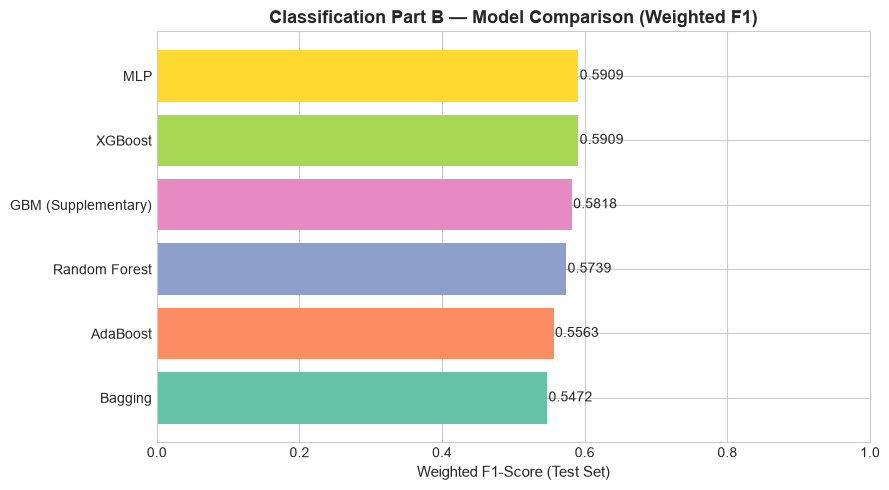

In [13]:
# Bar chart: Weighted-F1 comparison
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(partB_table['Algorithm'][::-1], partB_table['Weighted_F1'][::-1],
               color=sns.color_palette('Set2', len(partB_table)))
for bar, val in zip(bars, partB_table['Weighted_F1'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10)
ax.set_xlim(0, 1.0)
ax.set_xlabel('Weighted F1-Score (Test Set)', fontsize=11)
ax.set_title('Classification Part B — Model Comparison (Weighted F1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


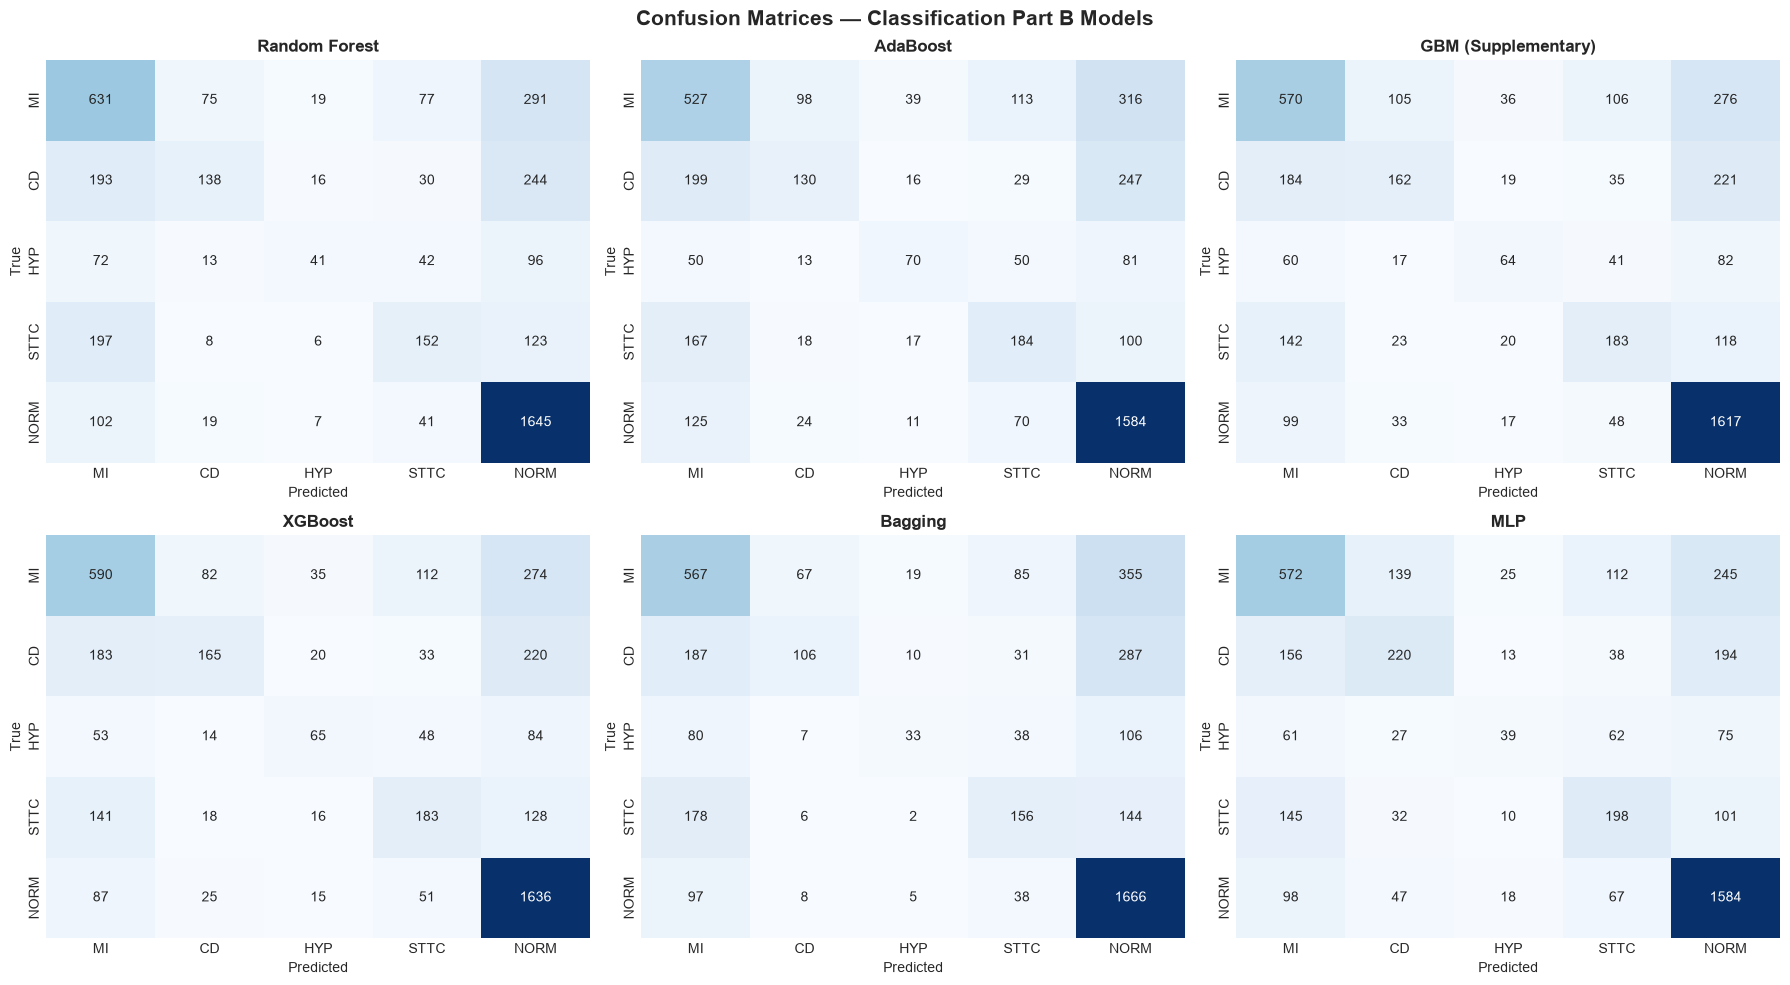

In [14]:
# Confusion matrices for all Part B models
n_models  = len(clf_cms)
n_cols    = 3
n_rows    = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes      = axes.flatten()

for idx, (m_name, cm) in enumerate(clf_cms.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(m_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — Classification Part B Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
# Per-class classification report for the best Part B model
best_partB_name  = partB_table.iloc[0]['Algorithm']
best_partB_model = clf_models[best_partB_name]
best_partB_pipe  = clf_pipelines[best_partB_name]

if best_partB_name == 'XGBoost':
    raw_preds    = best_partB_model.predict(X_test)
    best_preds_str = le.inverse_transform(raw_preds)
else:
    best_preds_str = best_partB_model.predict(X_test)

print(f"Best Part B model: {best_partB_name}")
print()
print(classification_report(y_test_str, best_preds_str, labels=class_names, target_names=class_names, zero_division=0))

# Serialize self-contained pipeline (BUG-13)
joblib.dump({
    'pipeline': best_partB_pipe,
    'feature_names': feature_cols,
    'class_names': class_names,
    'label_encoder': le if best_partB_name == 'XGBoost' else None
}, os.path.join(MODELS_DIR, 'best_classification_pipeline_partB.joblib'))

joblib.dump(best_partB_model, os.path.join(MODELS_DIR, 'best_classification_model_partB.joblib'))
print(f"Serialized complete pipeline for {best_partB_name} to /models/best_classification_pipeline_partB.joblib")


Best Part B model: MLP

              precision    recall  f1-score   support

          MI       0.55      0.52      0.54      1093
          CD       0.47      0.35      0.41       621
         HYP       0.37      0.15      0.21       264
        STTC       0.42      0.41      0.41       486
        NORM       0.72      0.87      0.79      1814

    accuracy                           0.61      4278
   macro avg       0.51      0.46      0.47      4278
weighted avg       0.59      0.61      0.59      4278

Serialized complete pipeline for MLP to /models/best_classification_pipeline_partB.joblib


---
## Section D: Feature Importances — Best Ensemble Model (BUG-05 Fix)


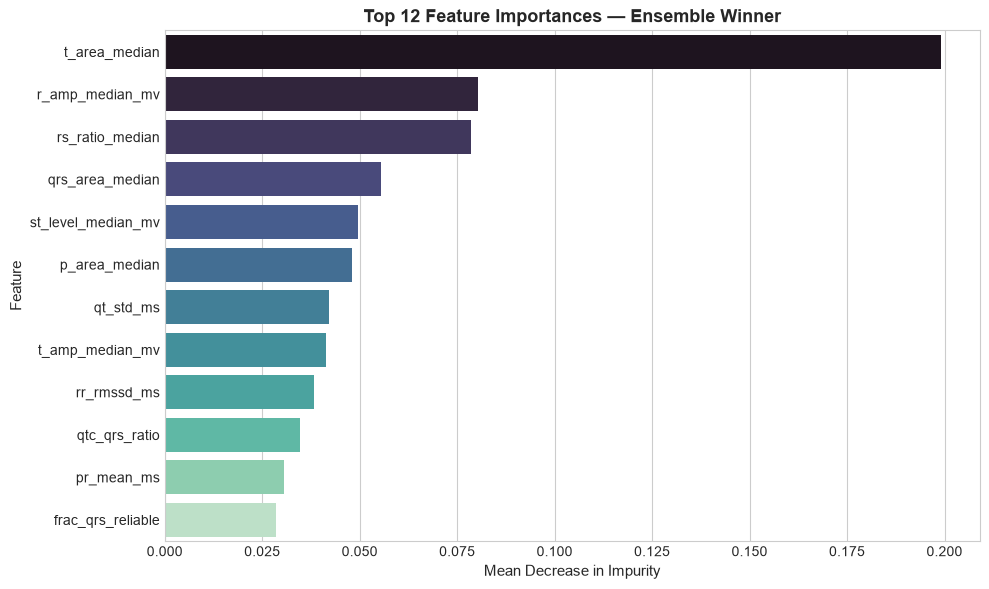

In [16]:
# Show feature importances with length check matching feature_cols (BUG-05)
feat_model = clf_models.get(best_partB_name) if hasattr(clf_models.get(best_partB_name), 'feature_importances_') else (
    clf_models.get('XGBoost') or clf_models.get('Random Forest') or clf_models.get('GBM (Supplementary)') or clf_models.get('AdaBoost')
)
if feat_model and hasattr(feat_model, 'feature_importances_'):
    importances = feat_model.feature_importances_
    if len(feature_cols) != len(importances):
        raise ValueError(f"Feature column length ({len(feature_cols)}) does not match importance vector length ({len(importances)})")
    
    imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df.head(12), x='Importance', y='Feature', palette='mako')
    model_name = best_partB_name if hasattr(clf_models.get(best_partB_name), 'feature_importances_') else 'Ensemble Winner'
    plt.title(f'Top 12 Feature Importances — {model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Mean Decrease in Impurity', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for the selected model.")


---
## Section E: Consolidated 10-Algorithm Benchmark Table (Review 2 Deliverable — Rubric A2)

This consolidated table unifies all 5 baseline models from **Part A** and all 5 primary models from **Part B**
(excluding GBM as supplementary). Evaluated on the identical patient-stratified 80:20 test split ($N=4,278$),
reporting **Accuracy**, **Weighted Precision**, **Weighted Recall**, **Weighted F1-Score**, **Macro F1-Score**, and **One-vs-Rest ROC-AUC**.


In [17]:
partA_path = os.path.join(DATA_DIR, 'partA_results.csv')
if os.path.exists(partA_path):
    partA_df = pd.read_csv(partA_path)
    partA_df['Track'] = 'Part A (Baseline)'
else:
    print("WARNING: partA_results.csv not found.")
    partA_df = pd.DataFrame()

partB_df = partB_table.copy()
partB_df['Track'] = 'Part B (Ensemble/Neural)'

# Combine both tracks
consolidated_df = pd.concat([partA_df, partB_df], ignore_index=True)

# Required 10 algorithms
req_10 = [
    'Logistic Regression', 'K-Nearest Neighbors', 'Gaussian Naive Bayes',
    'Decision Tree', 'Support Vector Classifier', 'Random Forest',
    'AdaBoost', 'XGBoost', 'Bagging', 'MLP'
]

table_10 = consolidated_df[consolidated_df['Algorithm'].isin(req_10)].copy()
table_10 = table_10.sort_values(by='Weighted_F1', ascending=False).reset_index(drop=True)
table_10.index = np.arange(1, len(table_10) + 1)

display_cols = ['Algorithm', 'Track', 'Accuracy', 'Precision_Weighted', 'Recall_Weighted', 'Weighted_F1', 'Macro_F1', 'ROC_AUC_OvR']
display_cols = [c for c in display_cols if c in table_10.columns]

print("=" * 105)
print("CONSOLIDATED 10-ALGORITHM BENCHMARK TABLE (REVIEW 2 DELIVERABLE — RUBRIC A2)")
print("=" * 105)
display(table_10[display_cols])

# Save consolidated table to data/
table_10[display_cols].to_csv(os.path.join(DATA_DIR, 'consolidated_10_algorithms.csv'), index=False)
print("Saved consolidated benchmark to ../data/consolidated_10_algorithms.csv")


CONSOLIDATED 10-ALGORITHM BENCHMARK TABLE (REVIEW 2 DELIVERABLE — RUBRIC A2)


,Algorithm,Track,Accuracy,Precision_Weighted,Recall_Weighted,Weighted_F1,Macro_F1,ROC_AUC_OvR
1,XGBoost,Part B (Ensemble/Neural),0.6169,0.5933,0.6169,0.5909,0.4816,0.8405
2,MLP,Part B (Ensemble/Neural),0.6108,0.5858,0.6108,0.5909,0.4711,0.8438
3,Random Forest,Part B (Ensemble/Neural),0.6094,0.5838,0.6094,0.5739,0.4495,0.8317
4,Support Vector Classifier,Part A (Baseline),0.5589,0.5963,0.5589,0.5674,0.4786,0.8396
5,AdaBoost,Part B (Ensemble/Neural),0.5832,0.5564,0.5832,0.5563,0.4542,0.8021
6,Bagging,Part B (Ensemble/Neural),0.5909,0.5665,0.5909,0.5472,0.4219,0.8058
7,Logistic Regression,Part A (Baseline),0.5147,0.5600,0.5147,0.5241,0.4427,0.8039
8,K-Nearest Neighbors,Part A (Baseline),0.5676,0.5340,0.5676,0.5206,0.3941,0.7862
9,Gaussian Naive Bayes,Part A (Baseline),0.5337,0.5271,0.5337,0.5093,0.4158,0.7714
10,Decision Tree,Part A (Baseline),0.4937,0.5433,0.4937,0.4998,0.4200,0.7599


Saved consolidated benchmark to ../data/consolidated_10_algorithms.csv


---
## References & Citations
1. Wagner, P., et al. (2020). *PTB-XL, a large publicly available electrocardiography dataset*. Scientific Data, 7(1), 154.
2. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825-2830.
